In [2]:
from dataclasses import dataclass
from pathlib import Path
import argparse
import cv2
import numpy as np
import matplotlib.pyplot as plt
# set up root directory
root_dir = Path("/Users/erinwong/Documents/braillic/IR_tracking/Tracking-ML2InfraredTracking/desktop")

In [17]:
raw_depth_far = np.load(root_dir / "ml2_depth_far.npy")
raw_depth_near = np.load(root_dir / "ml2_depth_near.npy")
print(raw_depth_far.shape)

(480, 544)


In [35]:
## analyze near vs far depth frames
def plot_depth_frames_thresholded(frames, threshold_method, fixed_threshold: int = 200, top_p: tuple = (100, 90), fig_name: str = "Near vs far Depth RAW comparison"):
    vmax = 3000  # shared display range (Depth RAW scale)

    if threshold_method == "fixed":
        threshold = fixed_threshold
        thresholded = {
            name: np.where(depth >= threshold, depth, 0)
            for name, depth in frames.items()
        }
    elif threshold_method == "percentile":
        thresholded = {
            name: np.where(depth >= max(top_p[0], np.percentile(depth, top_p[1])), depth, 0)
            for name, depth in frames.items()
        }
    else:
        raise ValueError(f"Invalid threshold method: {threshold_method}")

    fig, axes = plt.subplots(2, 4, figsize=(16, 8))

    for row, name in enumerate(("near", "far")):
        depth = frames[name]
        thresh = thresholded[name]

        axes[row, 0].imshow(depth, vmin=0, vmax=vmax)
        axes[row, 0].set_title(f"{name} raw")
        axes[row, 0].axis("off")

        axes[row, 1].hist(depth.flatten(), bins=256, range=(0, 256))
        axes[row, 1].set_title(f"{name} histogram (0–256)")

        axes[row, 2].imshow(thresh, vmin=0, vmax=vmax)
        if threshold_method == "fixed":
            axes[row, 2].set_title(f"{name} thresholded (≥ {threshold})")
        elif threshold_method == "percentile":
            axes[row, 2].set_title(f"{name} thresholded (≥ {top_p}% percentile)")
        axes[row, 2].axis("off")

        axes[row, 3].hist(thresh.flatten(), bins=256, range=(1, 256))
        axes[row, 3].set_title(f"{name} hist (thresholded, exclude 0)")

    fig.suptitle(fig_name, y=1.02)
    fig.tight_layout()
    plt.show()

In [36]:
## mimicking processing
raw_min = 5
raw_max = 3000
def colourise_depth(depth: np.ndarray) -> np.ndarray:
    finite = np.isfinite(depth)

    # Exact CPU equivalent of DepthSensorShader.shader for _Buffer == 0:
    # saturate((depth - _RawMin) / (_RawMax - _RawMin)).
    normalized = ((np.where(finite, depth, raw_min) - raw_min) /
                    max(raw_max - raw_min, 1e-6))
    normalized = np.clip(normalized, 0.0, 1.0)
    # if args.unity_color_space == "linear":
        # The project uses Linear color space. Unity converts the shader's
        # linear output to sRGB, while OpenCV byte images are already sRGB.
    normalized = np.where(
        normalized <= 0.0031308,
        normalized * 12.92,
        1.055 * np.power(normalized, 1.0 / 2.4) - 0.055,
    )
    grey = np.rint(normalized * 255.0).astype(np.uint8)
    grey[~finite] = 0
    return cv2.cvtColor(grey, cv2.COLOR_GRAY2BGR)

    # valid = finite & (depth > 0)
    # clipped = np.clip(np.where(valid, depth, args.near), args.near, args.far)
    # grey = ((clipped - args.near) *
    #         (255.0 / max(args.far - args.near, 1e-6))).astype(np.uint8)
    # grey[~valid] = 0
    # colour = cv2.applyColorMap(255 - grey, cv2.COLORMAP_TURBO)
    # colour[~valid] = 0
    # return colour
colour_far = colourise_depth(raw_depth_far)
colour_near = colourise_depth(raw_depth_near)

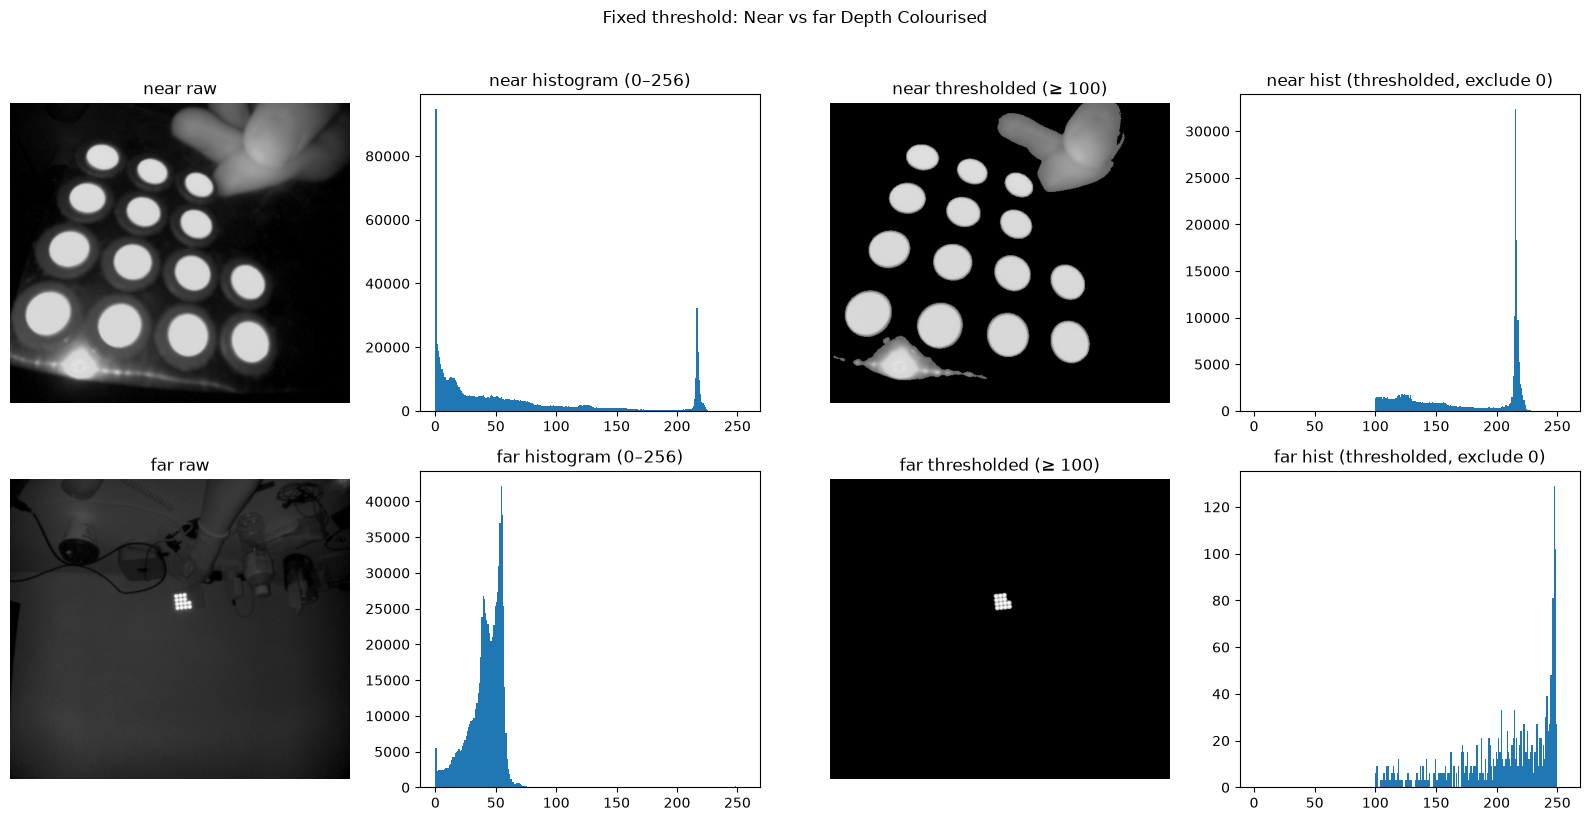

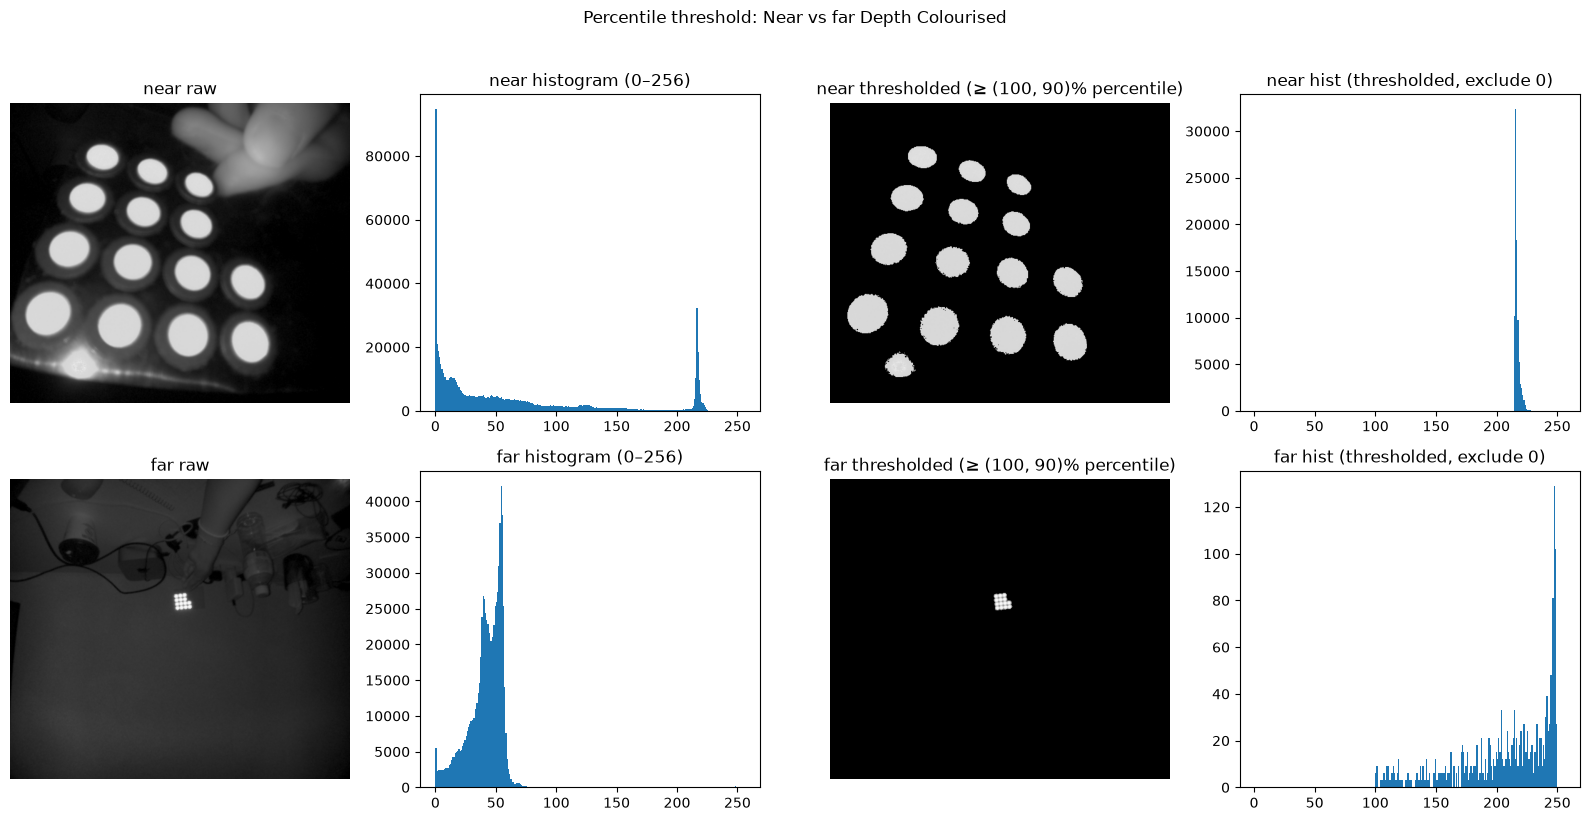

In [39]:
raw_frames = {
    "near": raw_depth_near,
    "far": raw_depth_far,
}
colour_frames = {
    "near": colour_near,
    "far": colour_far,
}
# plot_depth_frames_thresholded(raw_frames, threshold_method="fixed", fixed_threshold=200, fig_name="Fixed threshold: Near vs far Depth RAW")
plot_depth_frames_thresholded(colour_frames, threshold_method="fixed", fixed_threshold=100, fig_name="Fixed threshold: Near vs far Depth Colourised")

# plot_depth_frames_thresholded(raw_frames, threshold_method="percentile", fig_name="Percentile threshold: Near vs far Depth RAW")
plot_depth_frames_thresholded(colour_frames, threshold_method="percentile", fig_name="Percentile threshold: Near vs far Depth Colourised")